# Spotify Songs — Exploratory Data Analysis

`spotify_songs.csv` — 32,833 rows x 23 columns
Source: [30000 Spotify Songs](https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs)
on Kaggle, collected from the Spotify API via the `spotifyr` package.

## Setup

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.min_rows", 20)
sns.set_theme(style="whitegrid")

path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")
df_raw = pd.read_csv(f"{path}/spotify_songs.csv")
df = df_raw.copy()

df.shape

/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 3.01M/3.01M [00:00<00:00, 3.61MB/s]

Extracting files...


(32833, 23)

## Part 1 — Dataset Understanding

### Data dictionary

| Column | Type | Meaning |
|---|---|---|
| track_id | text | Spotify song identifier |
| track_name | text | song title |
| track_artist | text | performing artist |
| track_popularity | 0–100 | Spotify popularity score |
| track_album_id / name | text | album the song belongs to |
| track_album_release_date | text | album release date |
| playlist_name / id | text | playlist the row came from |
| playlist_genre | 6 values | genre of the playlist |
| playlist_subgenre | 24 values | subgenre of the playlist |
| danceability | 0–1 | steady beat, suitable for dancing |
| energy | 0–1 | fast, loud, noisy |
| key | 0–11 | pitch class |
| loudness | −60–0 dB | average volume, negative is normal |
| mode | 0 / 1 | minor / major |
| speechiness | 0–1 | presence of spoken words |
| acousticness | 0–1 | confidence the track is acoustic |
| instrumentalness | 0–1 | above 0.5 means likely no vocals |
| liveness | 0–1 | above 0.8 means likely a live recording |
| valence | 0–1 | 0 sad, 1 happy |
| tempo | BPM | beats per minute |
| duration_ms | ms | track length |

In [2]:
numeric = df.select_dtypes(include=np.number).columns.tolist()
categorical = df.select_dtypes(exclude=np.number).columns.tolist()

print("numerical  ", len(numeric), numeric)
print()
print("categorical", len(categorical), categorical)

numerical   13 ['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

categorical 10 ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']


### Answers

**1. What is the purpose of this dataset?**
- it describes songs by their audio features, like danceability, energy and tempo, and puts a
popularity score next to each one, so how a song sounds can be compared to how well it did.

**2. What does each row represent?**
- one song inside one playlist. the same song comes back for every playlist it's in, so there are
32,833 rows but only 28,356 songs.

**3. How many rows and columns are there?**
- 32,833 rows and 23 columns.

**4. Which features are numerical?**
- 13, `track_popularity`, `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`,
`acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo` and `duration_ms`. `key` and
`mode` are numbers on paper, but they're really categories, so they get fixed in 3.3.

**5. Which features are categorical?**
- 10, `track_id`, `track_name`, `track_artist`, `track_album_id`, `track_album_name`,
`track_album_release_date`, `playlist_name`, `playlist_id`, `playlist_genre` and
`playlist_subgenre`. the release date is here because it's saved as text.

**6. Is there a target variable? If yes, what is it?**
- yes, `track_popularity`. it's the outcome, it only happens after people play the song, and
nothing else in the table comes from it. it works for regression as it is, or for classification
once it's cut into classes (3.7). `playlist_genre` could be a target too, but it labels the
playlist and not the song.

## Part 2 — Initial Exploration

In [3]:
print("shape:", df.shape)
print()
print(df.columns.tolist())

shape: (32833, 23)

['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.0,42.477081,24.984074,0.000000,24.0000,45.000000,62.00000,100.000
danceability,32833.0,0.654850,0.145085,0.000000,0.5630,0.672000,0.76100,0.983
energy,32833.0,0.698619,0.180910,0.000175,0.5810,0.721000,0.84000,1.000
key,32833.0,5.374471,3.611657,0.000000,2.0000,6.000000,9.00000,11.000
loudness,32833.0,-6.719499,2.988436,-46.448000,-8.1710,-6.166000,-4.64500,1.275
mode,32833.0,0.565711,0.495671,0.000000,0.0000,1.000000,1.00000,1.000
speechiness,32833.0,0.107068,0.101314,0.000000,0.0410,0.062500,0.13200,0.918
acousticness,32833.0,0.175334,0.219633,0.000000,0.0151,0.080400,0.25500,0.994
instrumentalness,32833.0,0.084747,0.224230,0.000000,0.0000,0.000016,0.00483,0.994
liveness,32833.0,0.190176,0.154317,0.000000,0.0927,0.127000,0.24800,0.996


In [6]:
df.describe(include="str").T

,count,unique,top,freq
track_id,32833,28356,7BKLCZ1jbUBVqRi2FVlTVw,10
track_name,32828,23449,Poison,22
track_artist,32828,10692,Martin Garrix,161
track_album_id,32833,22545,5L1xcowSxwzFUSJzvyMp48,42
track_album_name,32828,19743,Greatest Hits,139
track_album_release_date,32833,4530,2020-01-10,270
playlist_name,32833,449,Indie Poptimism,308
playlist_id,32833,471,4JkkvMpVl4lSioqQjeAL0q,247
playlist_genre,32833,6,edm,6043
playlist_subgenre,32833,24,progressive electro house,1809


In [7]:
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


### Answers

**1. What did you notice immediately?**
- `track_id` has 28,356 unique values in 32,833 rows, so about 1 row in 7 is a repeat. `loudness`
is negative all the way down, which looks broken but that's just decibels. `duration_ms` is too
big to read, and the mean `key` of 5.37 doesn't mean anything.

**2. Are there any obvious problems?**
- the release date is text, `key` and `mode` are the wrong type, and there are 0s sitting in
`tempo`, `energy` and `track_popularity`. `info()` also shows 32,828 non-null out of 32,833 in
three text columns.

**3. Which columns require further investigation?**
- `track_id`, `track_album_release_date`, `tempo`, `duration_ms`, `track_popularity`, and the
three name columns.

## Part 3 — Data Quality Assessment

### 3.1 Missing values

In [8]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percent": (df.isna().mean() * 100).round(3),
})
missing[missing["missing"] > 0]

,missing,percent
track_name,5,0.015
track_artist,5,0.015
track_album_name,5,0.015


In [9]:
df[df["track_name"].isna()]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
8151,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,HIP&HOP,5DyJsJZOpMJh34WvUrQzMV,rap,southern hip hop,0.714,0.821,6,-7.635,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707
9282,5cjecvX0CmC9gK0Laf5EMQ,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,gangster rap,0.678,0.659,11,-5.364,0,0.3190,0.0534,0.00000,0.5530,0.191,146.153,202235
9283,5TTzhRSWQS4Yu8xTgAuq6D,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,gangster rap,0.465,0.820,10,-5.907,0,0.3070,0.0963,0.00000,0.0888,0.505,86.839,206465
19568,3VKFip3OdAvv4OfNTgFWeQ,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,Reggaeton viejito🔥,0si5tw70PIgPkY1Eva6V8f,latin,reggaeton,0.675,0.919,11,-6.075,0,0.0366,0.0606,0.00653,0.1030,0.726,97.017,252773
19811,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,latin hip hop,3nH8aytdqNeRbcRCg3dw9q,latin,latin hip hop,0.714,0.821,6,-7.635,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707


In [10]:
before = len(df)
df = df.dropna(subset=["track_name", "track_artist", "track_album_name"])
print(before, "->", len(df))

32833 -> 32828


### Answers

**1. Which columns contain missing values?**
- three, all text, `track_name`, `track_artist` and `track_album_name`. every other column is
full.

**2. What percentage of each column is missing?**
- 0.015% each, 5 cells out of 32,833. all three are empty in the same 5 rows, so it's 5 bad rows,
not three bad columns. the csv writes them as `NA`, which pandas reads as missing on its own.

**3. What is your chosen treatment?**
- dropped the 5 rows, 32,833 → 32,828.

**4. Why did you choose this approach?**
- you can't guess a song title. a median works for a number and a mode works for a category, but
a name has no fair guess, and `"Unknown"` is just a placeholder. 0.015% is too small to change
anything.

### 3.2 Duplicate rows

In [11]:
print("exact duplicate rows:", df.duplicated().sum())
print("duplicate track_id  :", df["track_id"].duplicated().sum())
print("unique songs        :", df["track_id"].nunique())

exact duplicate rows: 0
duplicate track_id  : 4476
unique songs        : 28352


In [12]:
repeated = df["track_id"].value_counts().index[0]
df[df["track_id"] == repeated][["track_name", "track_artist", "playlist_genre", "playlist_name"]]

,track_name,track_artist,playlist_genre,playlist_name
133,Closer (feat. Halsey),The Chainsmokers,pop,Dance Pop
1731,Closer (feat. Halsey),The Chainsmokers,pop,Post pop teen
2478,Closer (feat. Halsey),The Chainsmokers,pop,Electropop Hits 2017-2020
4535,Closer (feat. Halsey),The Chainsmokers,pop,A Loose Definition of Indie Poptimism
7369,Closer (feat. Halsey),The Chainsmokers,rap,◤ Hip Hop Dance Music – Urban – Trap – Breakin...
17467,Closer (feat. Halsey),The Chainsmokers,latin,Tropical House Run 190 BPM
18358,Closer (feat. Halsey),The Chainsmokers,latin,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥
19770,Closer (feat. Halsey),The Chainsmokers,latin,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥
23784,Closer (feat. Halsey),The Chainsmokers,r&b,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥
30629,Closer (feat. Halsey),The Chainsmokers,edm,2015 songs


In [13]:
songs = df.drop_duplicates(subset="track_id")

print("mean popularity, all rows    :", round(df["track_popularity"].mean(), 2))
print("mean popularity, unique songs:", round(songs["track_popularity"].mean(), 2))

mean popularity, all rows    : 42.48
mean popularity, unique songs: 39.34


### Answers

**1. Are duplicate rows present?**
- no exact duplicate rows, `df.duplicated().sum()` gives 0. but 4,476 rows repeat a `track_id`,
which leaves 28,352 songs. "Closer" by The Chainsmokers shows up 10 times, once per playlist.

**2. Should they be removed?**
- no. a row is a song inside a playlist, so a repeat is real, not a mistake. removing them throws
away the playlist column, which is the only part that's different.

**3. Explain your decision.**
- kept everything, and made `songs` as a de-duplicated view for song-level numbers. the repeats
do pull averages up, because popular songs sit in more playlists, mean popularity is 42.48 across
rows and 39.34 across songs. both are right, they just answer different questions.

### 3.3 Wrong data types

In [14]:
df.dtypes

track_id                        str
track_name                      str
track_artist                    str
track_popularity              int64
track_album_id                  str
track_album_name                str
track_album_release_date        str
playlist_name                   str
playlist_id                     str
playlist_genre                  str
playlist_subgenre               str
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

In [15]:
df["duration_min"] = df["duration_ms"] / 60000
df["key"] = df["key"].astype("category")
df["mode"] = df["mode"].astype("category")

df[["key", "mode", "duration_min"]].dtypes

key             category
mode            category
duration_min     float64
dtype: object

In [16]:
strict = pd.to_datetime(df["track_album_release_date"], errors="coerce")
mixed = pd.to_datetime(df["track_album_release_date"], format="mixed", errors="coerce")

print("failed with the default parser:", strict.isna().sum())
print("failed with format='mixed'    :", mixed.isna().sum())

failed with the default parser: 1886
failed with format='mixed'    : 0


In [17]:
df["track_album_release_date"].str.len().value_counts() # YYYY-MM-DD

track_album_release_date
10    30942
4      1855
7        31
Name: count, dtype: int64

In [18]:
df["date_precision"] = df["track_album_release_date"].str.len().map({4: "year", 7: "month", 10: "day"})
df["release_date"] = mixed
df["release_year"] = df["track_album_release_date"].str[:4].astype(int)

df["date_precision"].value_counts()

date_precision
day      30942
year      1855
month       31
Name: count, dtype: int64

### Answers

**1. Are any columns stored using incorrect data types?**
- three. the release date is text where a date should be, `key` and `mode` are whole numbers even
though they're categories, and `duration_ms` is the right type in a unit nobody can read.

**2. How did you identify them?**
- `dtypes` shows the date as `str`. `key` and `mode` showed up in `describe()` instead, a mean
key of 5.37 is a number you can work out but can't read. for the date, both parsers were run, the
default one fails on 1,886 rows and `format="mixed"` fails on none. `str.len()` shows why, there
are three formats, `2019-06-14` (30,942 rows), `1981-12` (31) and `2012` (1,855).

**3. How did you correct them?**
- `key` and `mode` cast to `category`, `duration_min` added next to `duration_ms`, and the date
parsed with `format="mixed"`.

  both parsers cost something, the default one deletes 5.7% of the rows, and mixed turns `2012`
into `2012-01-01`, which makes up a day that was never written down. so `date_precision` marks
how exact each date is, and `release_year` is taken from the text. the year is right either way,
so it's the only date field used later.

### 3.4 Invalid values

In [19]:
checks = {
    "tempo 0 or less": (df["tempo"] <= 0).sum(),
    "duration under 10s": (df["duration_ms"] < 10000).sum(),
    "loudness above 0 dB": (df["loudness"] > 0).sum(),
    "popularity = 0": (df["track_popularity"] == 0).sum(),
}
pd.Series(checks)

tempo 0 or less           1
duration under 10s        1
loudness above 0 dB       6
popularity = 0         2698
dtype: int64

In [20]:
df.nsmallest(6, "duration_ms")[["track_name", "track_artist", "tempo", "duration_min",
                                "track_popularity"]]

,track_name,track_artist,tempo,duration_min,track_popularity
11363,"Hi, How're You Doin'?",DREAMS COME TRUE,0.000,0.066667,0
8339,The Screwed Up Click,DJ Screw & The Screwed Up Click,85.811,0.491550,0
28161,The Reddish Flower,Rob Stepwart,126.059,0.523817,13
28142,Poison (Interlude),Tetengo,128.068,0.531250,18
24510,No Guarantee - Remix Version,Chico DeBarge,128.899,0.531550,0
28135,WTF (Interlude),Semser,132.501,0.562500,16


In [21]:
before = len(df)
df = df[df["duration_ms"] >= 10000]

print(before, "->", len(df))
print("tempo 0 or less remaining:", (df["tempo"] <= 0).sum())
print("lowest tempo now         :", df["tempo"].min())

32828 -> 32827
tempo 0 or less remaining: 0
lowest tempo now         : 35.477


### Answers

**1. Explain how you detected them.**
- by writing down what each column is allowed to hold, then counting the rows that break it:

  | check | count | verdict |
  |---|---|---|
  | tempo 0 or less | 1 | impossible, a song can't have no beat |
  | duration under 10s | 1 | 4 seconds, that isn't a track |
  | loudness above 0 dB | 6 | fine, the highest is +1.27 dB |
  | popularity = 0 | 2,698 | fine, it means nobody played it |

  both of the first two checks point at the same row. "Hi, How're You Doin'?" is 4 seconds long
*and* has a tempo of 0, and that isn't two faults, there just isn't enough audio in a 4 second
clip to find a beat in. spotify's own analyser gave up on it and returned 0, which is the useful
part, the file itself is telling you the audio was too short to measure.

**2. Explain how you treated them.**
- dropped that 1 row, 32,828 → 32,827. it takes the zero tempo away with it, so nothing needed
filling in, and the lowest tempo left is 35.48.

  the 10 second line comes from a gap in the data rather than from a round number. sorted by
length the shortest track is 4 seconds and the next one is 29.5, so there's a 25.5 second hole
between them, and above that they sit about 2 seconds apart. any cutoff between 5 and 29.4
seconds drops the same single row, so the answer doesn't depend on where the line goes.

  a 30 second rule was the first thing tried and it's the one value in that whole range that
changes the answer. it dropped a 29.5 second interlude while keeping a 31.4 second one, and there
are several tracks called "Interlude" sitting at 31 to 35 seconds that stay in, so short tracks
are a normal part of this data and not a fault.

  the 6 loud ones stay, they're just loud. so do the zero popularity scores, 2,697 of the 2,698,
the missing one being the 4 second track that went anyway. that group matters, it's 8.2% of the
data and it looks like missing data, but 0 means nobody played it, and dropping them would remove
the failed songs which are the whole point of looking at popularity.

### 3.5 Inconsistent categories

In [22]:
for col in ["playlist_genre", "playlist_subgenre", "track_artist"]:
    normalized = df[col].str.strip().str.lower().nunique()
    print(f"{col:18} {df[col].nunique():6} unique -> {normalized} after strip and lower")

playlist_genre          6 unique -> 6 after strip and lower
playlist_subgenre      24 unique -> 24 after strip and lower
track_artist        10691 unique -> 10684 after strip and lower


In [23]:
collisions = df.groupby(df["track_artist"].str.lower())["track_artist"].unique()
collisions[collisions.apply(len) > 1]

track_artist
audrey       [audrey, Audrey]
cream          [CREAM, Cream]
davi             [Davi, DAVI]
gizmo          [gizmo, Gizmo]
mase             [Mase, MASE]
rainbow    [RAINBOW, Rainbow]
tobi             [TOBi, Tobi]
Name: track_artist, dtype: object

In [24]:
df[df["track_artist"].isin(["Cream", "CREAM"])][
    ["track_artist", "track_name", "track_album_release_date", "playlist_genre"]
].sort_values("track_artist")

,track_artist,track_name,track_album_release_date,playlist_genre
390,CREAM,LOVE + PARTY,2019-12-25,pop
405,CREAM,FUTARI x PARTY,2019-11-27,pop
11765,Cream,Sunshine Of Your Love,1967-11-02,rock
11778,Cream,White Room,1968-07-01,rock
12381,Cream,Sunshine Of Your Love,1967-11-02,rock
13024,Cream,Sunshine Of Your Love,1967-11-02,rock
13133,Cream,Sunshine Of Your Love,1995-03-07,rock
13397,Cream,White Room,2005-01-01,rock
13414,Cream,Sunshine Of Your Love,1967-11-02,rock
14474,Cream,Sunshine Of Your Love,1967-11-02,rock


In [25]:
df[df["track_name"] == "Since You Been Gone"][
    ["track_artist", "track_album_name", "track_album_release_date", "track_id"]
].drop_duplicates()

,track_artist,track_album_name,track_album_release_date,track_id
11933,RAINBOW,Rock,2003-01-01,0kYIsBXBR8bg8JN6xuqIDK
15005,Rainbow,Down To Earth (Deluxe Edition),1979,4N4guy1faBG6oseDnhjkWy
16145,Rainbow,Anthology,2009-01-01,6WU66nFWemwQyQNjCAfVPZ


In [26]:
conflicting = df.groupby("track_id")["playlist_genre"].nunique()

print("songs with more than one genre    :", (conflicting > 1).sum())
print("playlists with more than one genre:",
      (df.groupby("playlist_id")["playlist_genre"].nunique() > 1).sum(), "of", df["playlist_id"].nunique())

df[df["track_id"] == conflicting.idxmax()][["track_name", "playlist_genre", "playlist_name"]]

songs with more than one genre    : 1686
playlists with more than one genre: 5 of 471


,track_name,playlist_genre,playlist_name
344,bad guy,pop,Pop Warmup 130 BPM
1316,bad guy,pop,Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop
5260,bad guy,pop,Music&Other Drugs
13900,bad guy,rock,Permanent Wave
20109,bad guy,latin,Global Top 50 | 2020 Hits
22412,bad guy,r&b,urban CONTEMPORARY
23068,bad guy,r&b,Feeling Accomplished
30223,bad guy,edm,Charts 2020 🔥Top 2020🔥Hits 2020🔥Summer 2020🔥Po...


In [27]:
df["playlist_genre"].value_counts()

playlist_genre
edm      6043
rap      5743
pop      5507
r&b      5431
latin    5153
rock     4950
Name: count, dtype: int64

### Answers

**1. The problem**
- `playlist_genre` and `playlist_subgenre` are clean, lowercasing them leaves the counts at 6 and
24, because they come from a fixed list. `track_artist` is the messy one, it goes from 10,691
down to 10,684, so 7 pairs differ only in capital letters.

  a second problem turned up too, 1,686 songs (5.9%) have more than one genre, because the label
belongs to the playlist and not the song. "bad guy" by Billie Eilish is under all five of edm,
latin, pop, r&b and rock.

**2. Your cleaning process**
- checked the 7 pairs one by one instead of running `.str.lower()`, and that mattered:

  | pair | same artist? | evidence |
  |---|---|---|
  | `Rainbow` / `RAINBOW` | yes | same song, three releases, see below |
  | `Cream` / `CREAM` | **no** | 1967 rock (White Room) vs 2019 pop (LOVE + PARTY) |
  | `Mase` / `MASE` | unclear | 1997 rap vs 2019 rap |
  | `Tobi` / `TOBi`, `Audrey` / `audrey`, and 2 more | unclear | different genres, same year |

  "Since You Been Gone" shows where the spelling comes from. it appears three times under three
different `track_id` values, once on the 1979 album, once on a 2009 anthology and once on a 2003
compilation called "Rock", and only that last one credits the band in capitals. so the artist
name isn't a fixed field, it's whatever was typed into the metadata of that particular release.

  the genre cell shows the same kind of thing. only 5 of 471 playlists carry more than one genre,
so the label really does belong to the playlist, and the playlists "bad guy" sits in include
"Global Top 50 | 2020 Hits" filed under latin and an emoji-covered "Charts 2020" list filed under
edm. neither of those is a statement about the song.

**3. The final result**
- nothing was changed, both problems are just written down. lowercasing the artists is the
obvious fix and it's the wrong one, the same casing difference means two different bands in one
case and one band across two releases in another, and the string alone can't tell you which. only
48 rows out of 32,827 use any of these 14 spellings, and artist isn't used for grouping anywhere
here.

  the genre conflict can't be fixed without knowing which playlist someone came from, so it stays
as a limitation, genre results describe how playlists are built, not how songs are labelled.

### 3.6 Outliers

In [28]:
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


audio = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

summary = []
for col in audio:
    low, high = iqr_bounds(df[col])
    count = ((df[col] < low) | (df[col] > high)).sum()
    summary.append({
        "feature": col,
        "lower": round(low, 2),
        "upper": round(high, 2),
        "outliers": count,
        "percent": round(count / len(df) * 100, 1),
    })

pd.DataFrame(summary).sort_values("outliers", ascending=False)

,feature,lower,upper,outliers,percent
5,instrumentalness,-0.01,0.01,7030,21.4
3,speechiness,-0.10,0.27,3174,9.7
4,acousticness,-0.34,0.61,2205,6.7
6,liveness,-0.14,0.48,1842,5.6
9,duration_min,1.49,5.87,1386,4.2
2,loudness,-13.46,0.64,1020,3.1
8,tempo,49.02,184.85,570,1.7
0,danceability,0.27,1.06,290,0.9
1,energy,0.19,1.23,277,0.8
7,valence,-0.21,1.24,0,0.0


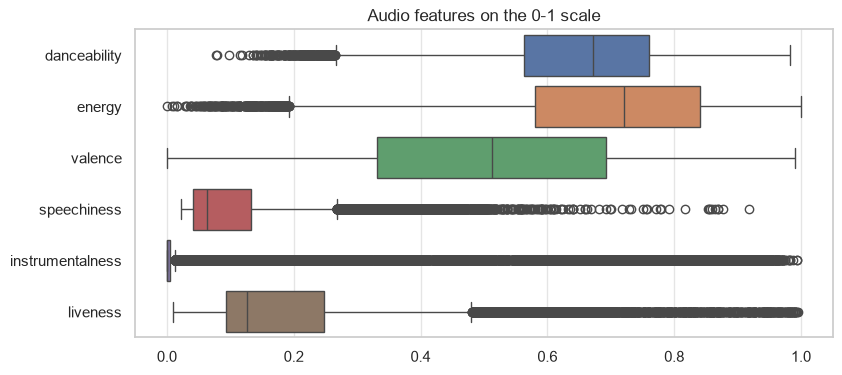

In [29]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df[["danceability", "energy", "valence", "speechiness",
                     "instrumentalness", "liveness"]], orient="h")
plt.title("Audio features on the 0-1 scale")
plt.show()

In [30]:
df[df["instrumentalness"] > 0.5][["track_name", "track_artist", "playlist_genre"]].head(8)

,track_name,track_artist,playlist_genre
45,Heaven Can Wait - The Aston Shuffle Remix,Sia,pop
169,With You - LöKii Remix,Kaskade,pop
202,Dreams Of You (feat. Rae Morris),Icarus,pop
342,Penny,Dimitri Vangelis & Wyman,pop
350,Shades Of Voices (Original Mix),PULLER,pop
353,Spirit Of Freedom,Dropgun,pop
361,Skyline,Catiso,pop
362,Callin' - Extended Mix,Lush & Simon,pop


### Answers

**1. How many outliers were found?**
- depends on the column. `instrumentalness` is the worst with 7,030 (21.4%), then `speechiness`
3,174 (9.7%), `acousticness` 2,205 (6.7%) and `liveness` 1,842 (5.6%). `valence` has none. IQR
was used instead of z-score, because these columns are skewed.

**2. Are they real observations or possible errors?**
- real. `instrumentalness` has a median of 0.000016, so the fence lands at 0.01 and anything
without vocals gets flagged, but 2,748 of them score above 0.5, which really does mean no vocals.
the flagged rows are remixes and electronic tracks. same story for `speechiness` with rap, and
`liveness` with live recordings.

**3. Did you keep, remove, or cap them?**
- kept, all of them.

**4. Justify your decision.**
- IQR measures how far a value sits from the middle, not whether it's correct. a track with no
vocals scoring high on `instrumentalness` is the measurement working, not breaking. the rows that
really were impossible were already gone by 3.4. dropping 21% of the rows would take out most of
the instrumental music, and bend every genre comparison in part 4.

### 3.7 Class imbalance

In [31]:
threshold = df["track_popularity"].quantile(0.75)
df["is_popular"] = df["track_popularity"] >= threshold

print("threshold (Q3):", threshold)

pd.DataFrame({
    "count": df["is_popular"].value_counts(),
    "percent": (df["is_popular"].value_counts(normalize=True) * 100).round(1),
})

threshold (Q3): 62.0


,count,percent
is_popular,,
False,24377,74.3
True,8450,25.7


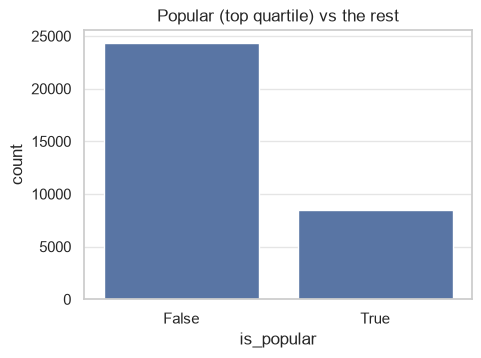

In [32]:
plt.figure(figsize=(5, 3.5))
sns.countplot(x=df["is_popular"])
plt.title("Popular (top quartile) vs the rest")
plt.show()

### Answers

**1. Is it balanced?**
- no. cut at the top quarter it comes out 25.7% popular against 74.3% not, so about 1 in 4.

**2. How did you measure it?**
- balance is a question about categories, and `track_popularity` is a 0-100 score, so there was
nothing to count until it was cut into classes. `is_popular` was added for that, set at Q3 (62).
the quarter mark comes from the data, a round number like 60 would just be a guess. after that
it's `value_counts()`. this column is only for this question, parts 4 to 6 go back to the number.

**3. Why is this important for machine learning?**
- because accuracy stops meaning anything. a model that says "not popular" every time scores
74.3% here and has learned nothing. so accuracy would be swapped for precision, recall and F1,
the train/test split would need to be stratified so both classes end up in the test set, and
class weights or resampling would be worth a try.

### Cleaning summary

In [33]:
df_clean = df.copy()

pd.DataFrame({
    "raw": [df_raw.shape[0], df_raw.shape[1], df_raw.isna().sum().sum(), df_raw["track_id"].nunique()],
    "clean": [df_clean.shape[0], df_clean.shape[1], df_clean.isna().sum().sum(), df_clean["track_id"].nunique()],
}, index=["rows", "columns", "missing cells", "unique songs"])

,raw,clean
rows,32833,32827
columns,23,28
missing cells,15,0
unique songs,28356,28351


6 rows removed out of 32,833, 5 with no name and 1 that was 4 seconds long. no value in any
surviving row was changed or filled in. five columns added, `duration_min`, `release_date`,
`release_year`, `date_precision` and `is_popular`.

the dataset was in decent shape already, so most of the work was deciding what not to touch. the
repeated songs, the negative loudness, the zero scores and the 21% of IQR outliers all look wrong
at first, and none of them are.

`df_clean` is used from here on.

## Part 4 — Exploratory Analysis

In [34]:
songs = df_clean.drop_duplicates(subset="track_id")

print("playlist rows:", len(df_clean))
print("unique songs :", len(songs))

playlist rows: 32827
unique songs : 28351


Anything about a song uses `songs`, anything about a genre or a playlist uses `df_clean`. this is
the split decided in 3.2.

### Numerical

In [35]:
numeric_features = ["track_popularity", "danceability", "energy", "loudness", "speechiness",
                    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
                    "duration_min"]

pd.DataFrame({
    "mean": songs[numeric_features].mean(),
    "median": songs[numeric_features].median(),
    "std": songs[numeric_features].std(),
    "skew": songs[numeric_features].skew(),
}).round(2)

,mean,median,std,skew
track_popularity,39.34,42.00,23.70,-0.23
danceability,0.65,0.67,0.15,-0.50
energy,0.70,0.72,0.18,-0.65
loudness,-6.82,-6.26,3.03,-1.35
speechiness,0.11,0.06,0.10,1.97
acousticness,0.18,0.08,0.22,1.58
instrumentalness,0.09,0.00,0.23,2.62
liveness,0.19,0.13,0.16,2.08
valence,0.51,0.51,0.23,-0.01
tempo,120.96,121.99,26.95,0.52


### Categorical

In [36]:
pd.DataFrame({
    "count": df_clean["playlist_genre"].value_counts(),
    "percent": (df_clean["playlist_genre"].value_counts(normalize=True) * 100).round(1),
})

,count,percent
playlist_genre,,
edm,6043,18.4
rap,5743,17.5
pop,5507,16.8
r&b,5431,16.5
latin,5153,15.7
rock,4950,15.1


In [37]:
df_clean["playlist_subgenre"].value_counts().head(8)

playlist_subgenre
progressive electro house    1809
southern hip hop             1674
indie poptimism              1672
latin hip hop                1655
neo soul                     1637
pop edm                      1517
electro house                1511
hard rock                    1485
Name: count, dtype: int64

In [38]:
df_clean.groupby("playlist_genre")["track_popularity"].agg(["mean", "median", "count"]).round(2) \
    .sort_values("mean", ascending=False)

,mean,median,count
playlist_genre,,,
pop,47.74,52.0,5507
latin,47.04,50.0,5153
rap,43.24,47.0,5743
rock,41.74,46.0,4950
r&b,41.22,44.0,5431
edm,34.83,36.0,6043


### Relationships

In [39]:
correlation = songs[numeric_features].corr().round(2)
correlation

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
track_popularity,1.00,0.05,-0.10,0.04,0.01,0.09,-0.12,-0.05,0.02,0.00,-0.14
danceability,0.05,1.00,-0.08,0.01,0.18,-0.03,-0.00,-0.13,0.33,-0.19,-0.09
energy,-0.10,-0.08,1.00,0.68,-0.03,-0.55,0.02,0.16,0.15,0.15,0.02
loudness,0.04,0.01,0.68,1.00,0.01,-0.37,-0.15,0.08,0.05,0.10,-0.11
speechiness,0.01,0.18,-0.03,0.01,1.00,0.02,-0.11,0.06,0.06,0.03,-0.10
acousticness,0.09,-0.03,-0.55,-0.37,0.02,1.00,-0.00,-0.07,-0.02,-0.11,-0.09
instrumentalness,-0.12,-0.00,0.02,-0.15,-0.11,-0.00,1.00,-0.01,-0.17,0.02,0.06
liveness,-0.05,-0.13,0.16,0.08,0.06,-0.07,-0.01,1.00,-0.02,0.02,0.01
valence,0.02,0.33,0.15,0.05,0.06,-0.02,-0.17,-0.02,1.00,-0.03,-0.03
tempo,0.00,-0.19,0.15,0.10,0.03,-0.11,0.02,0.02,-0.03,1.00,-0.00


In [40]:
correlation["track_popularity"].drop("track_popularity").sort_values(key=abs, ascending=False)

duration_min       -0.14
instrumentalness   -0.12
energy             -0.10
acousticness        0.09
danceability        0.05
liveness           -0.05
loudness            0.04
valence             0.02
speechiness         0.01
tempo               0.00
Name: track_popularity, dtype: float64

In [41]:
df_clean.groupby("playlist_genre")[["danceability", "energy", "valence", "speechiness",
                                    "acousticness", "duration_min"]].mean().round(3)

,danceability,energy,valence,speechiness,acousticness,duration_min
playlist_genre,,,,,,
edm,0.655,0.802,0.401,0.087,0.082,3.709
latin,0.713,0.708,0.605,0.103,0.211,3.614
pop,0.639,0.701,0.504,0.074,0.171,3.629
r&b,0.670,0.591,0.531,0.117,0.260,3.960
rap,0.718,0.651,0.505,0.197,0.193,3.569
rock,0.521,0.733,0.537,0.058,0.145,4.144


In [42]:
by_decade = df_clean.copy()
by_decade["decade"] = (by_decade["release_year"] // 10) * 10

by_decade[by_decade["decade"] >= 1970].pivot_table(
    index="playlist_genre", columns="decade", values="loudness", aggfunc="mean"
).round(2)

decade,1970,1980,1990,2000,2010,2020
playlist_genre,,,,,,
edm,-12.41,-10.37,-9.19,-6.66,-5.35,-6.27
latin,-5.61,-10.77,-9.10,-6.96,-5.99,-5.89
pop,-8.46,-9.30,-8.44,-6.02,-6.17,-7.25
r&b,-10.36,-11.23,-8.98,-7.52,-7.44,-7.18
rap,-8.26,-10.43,-7.91,-5.71,-7.09,-7.68
rock,-9.61,-8.62,-8.30,-6.44,-6.16,-5.40


### Answers

**1. Numerical analysis**
- popularity has a mean of 39.34 and a median of 42, and the mean is the lower one because 2,615
songs sit at 0. the skew column also explains 3.6, `instrumentalness` (2.62), `liveness` (2.08)
and `speechiness` (1.97) all lean hard to the right, which is why IQR flagged so much of them,
and `valence` is the only symmetric one at -0.01, which is why it flagged nothing.

**2. Categorical analysis**
- the six genres are close in size, 15.1% rock up to 18.4% edm, so no genre is too small to
compare. mean popularity runs from pop at 47.74 down to edm at 34.83, and edm is the biggest
genre in the dataset while scoring the lowest.

**3. Relationship analysis**
- `energy` and `loudness` are the strongest pair at +0.68, then `energy` and `acousticness` at
-0.55, and `danceability` and `valence` at +0.33. none of it reaches popularity, the biggest
correlation there is `duration_min` at -0.14 and everything else is under 0.13.

  the genre profiles show real differences, rock is the least danceable (0.521) and the longest
(4.14 min), edm has the most energy (0.802), latin the happiest valence (0.605), rap the most
speech (0.197) and r&b the most acoustic (0.260).

  the pivot table needs reading carefully. rock is the only genre with real numbers before 1990,
870 rows in the 1970s, and it does get louder, -9.61 up to -6.16. edm and latin have 4 rows each
in that decade, so those cells print a number but don't mean anything. the loudness trend is only
safe when the whole dataset is pooled, which is what chart 7 does.

## Part 5 — Data Visualization

### 1. Distribution of popularity

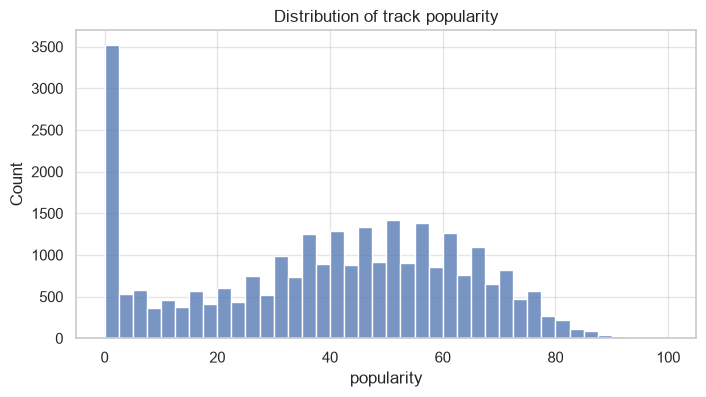

In [43]:
plt.figure(figsize=(8, 4))
sns.histplot(songs["track_popularity"], bins=40)
plt.title("Distribution of track popularity")
plt.xlabel("popularity")
plt.show()

**1. What does the chart show?**
- how popularity is spread across the 28,351 songs.

**2. What can be concluded from it?**
- most songs land between 20 and 60 with a median of 42, and there's a spike of 2,615 songs
(9.2%) stuck at 0. the mean is 39.34, below the median, and those zeros are the reason.

**3. Why is this information useful?**
- the zeros aren't missing data, they're songs nobody played, so the target piles up at one end
and any model has to deal with that.

### 2. Rows per genre

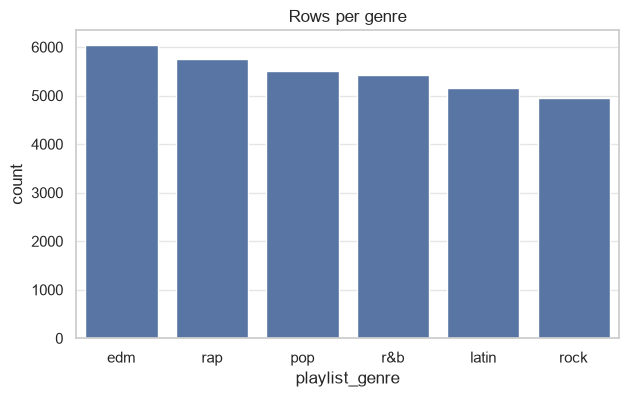

In [44]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="playlist_genre",
              order=df_clean["playlist_genre"].value_counts().index)
plt.title("Rows per genre")
plt.show()

**1. What does the chart show?**
- how many rows each of the six genres has.

**2. What can be concluded from it?**
- they're close together, from 4,950 rock up to 6,043 edm, so every genre sits between 15% and
18%.

**3. Why is this information useful?**
- no genre is rare, so the genre comparisons further down aren't resting on a small group.

### 3. Correlation heatmap

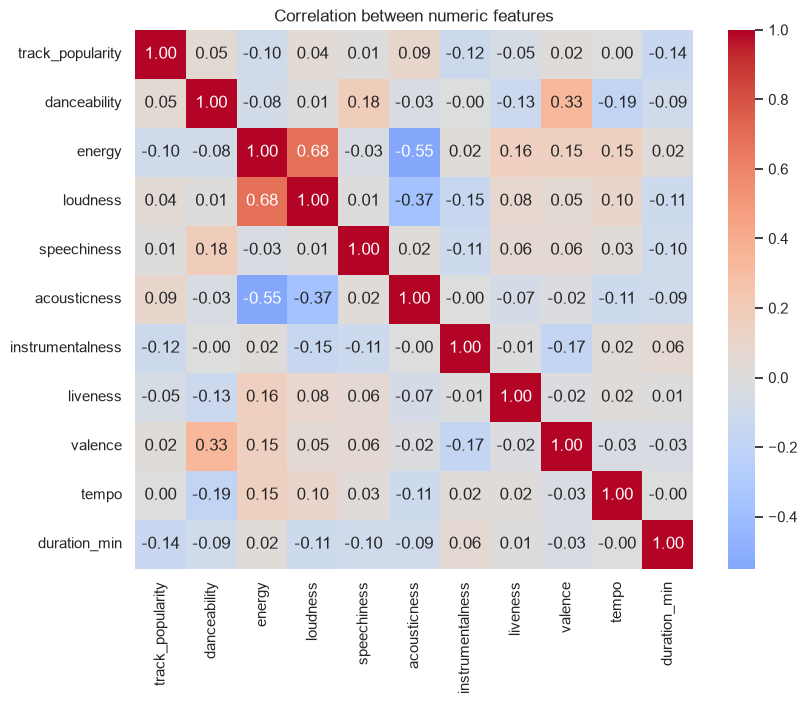

In [45]:
plt.figure(figsize=(9, 7))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric features")
plt.show()

**1. What does the chart show?**
- the correlation between all 11 numeric features, measured on songs.

**2. What can be concluded from it?**
- `energy` and `loudness` move together strongly (+0.68), `energy` and `acousticness` pull apart
(-0.55), and the whole `track_popularity` row is close to 0.

**3. Why is this information useful?**
- `energy` and `loudness` are saying almost the same thing, so a model only needs one of them,
and nothing in this table predicts popularity.

### 4. Energy by genre

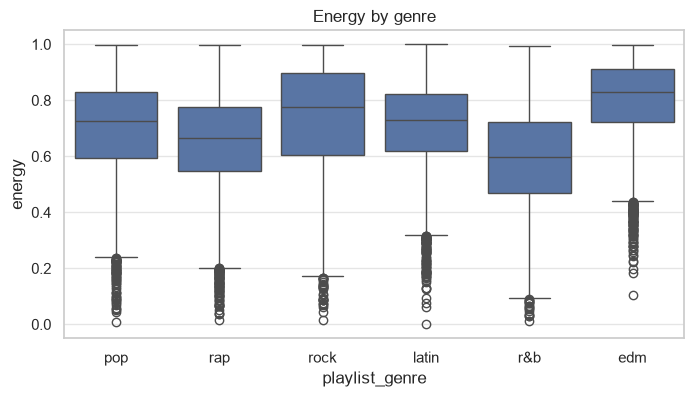

In [46]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x="playlist_genre", y="energy")
plt.title("Energy by genre")
plt.show()

**1. What does the chart show?**
- the spread of `energy` inside each genre, not just the average.

**2. What can be concluded from it?**
- edm is the highest at 0.80 and r&b the lowest at 0.59, and the two boxes don't overlap at all,
edm starts at 0.723 and r&b ends at 0.721.

**3. Why is this information useful?**
- genres really do sound different, so grouping by genre is worth doing instead of treating every
song as one pool.

### 5. Energy vs loudness

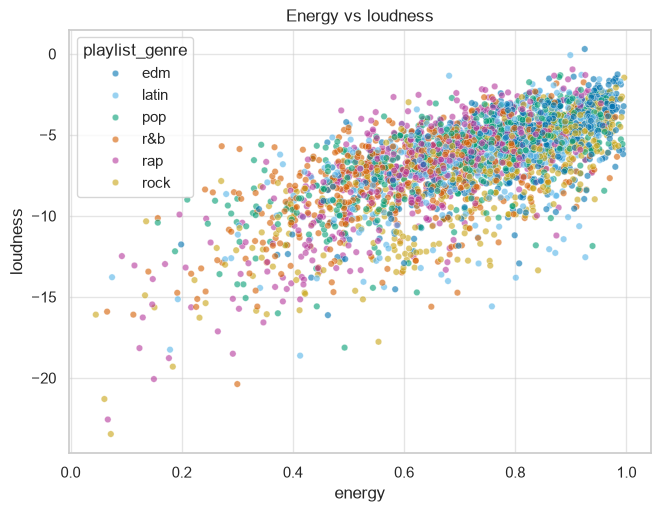

In [47]:
# the seaborn default puts several genres too close together to tell apart
genre_order = ["edm", "latin", "pop", "r&b", "rap", "rock"]
genre_colours = ["#0173b2", "#56b4e9", "#029e73", "#d55e00", "#b5379b", "#c8a415"]

sample = songs.sample(3000, random_state=1)

plt.figure(figsize=(7.5, 5.5))
sns.scatterplot(data=sample, x="energy", y="loudness", hue="playlist_genre",
                hue_order=genre_order, palette=genre_colours, alpha=0.6, s=22)
plt.title("Energy vs loudness")
plt.show()

**1. What does the chart show?**
- `energy` against `loudness` for a sample of 3,000 songs, coloured by genre.

**2. What can be concluded from it?**
- the slope is clear and every genre follows it, so it isn't one group creating the number. quiet
tracks are never high energy.

**3. Why is this information useful?**
- it confirms the +0.68 is a real relationship and not something one cluster produced, which is
what you'd want to check before dropping one of the two columns.

### 6. Mean popularity by genre

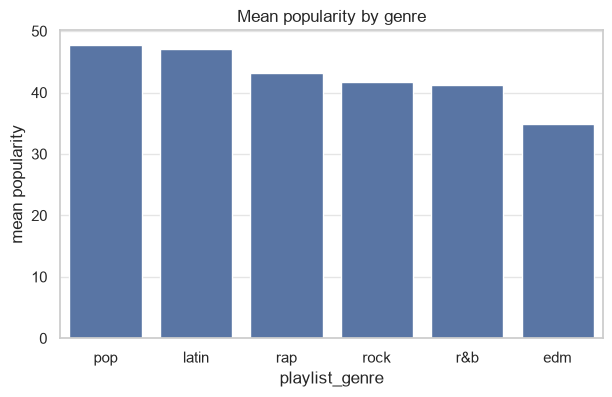

In [48]:
genre_popularity = df_clean.groupby("playlist_genre")["track_popularity"].mean() \
    .sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=genre_popularity.index, y=genre_popularity.values)
plt.title("Mean popularity by genre")
plt.ylabel("mean popularity")
plt.show()

**1. What does the chart show?**
- the mean popularity of each genre.

**2. What can be concluded from it?**
- pop is highest at 47.74 and edm lowest at 34.83, a gap of almost 13 points. edm has the most
rows in the whole dataset and the worst score.

**3. Why is this information useful?**
- more tracks doesn't mean more listeners, so how much of a genre exists says nothing about
demand for it.

### 7. Loudness over time

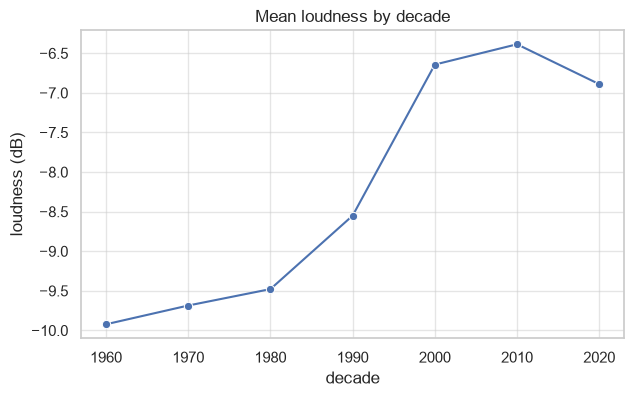

In [49]:
songs_by_decade = songs.copy()
songs_by_decade["decade"] = (songs_by_decade["release_year"] // 10) * 10
loudness_trend = songs_by_decade[songs_by_decade["decade"] >= 1960].groupby("decade")["loudness"].mean()

plt.figure(figsize=(7, 4))
sns.lineplot(x=loudness_trend.index, y=loudness_trend.values, marker="o")
plt.title("Mean loudness by decade")
plt.ylabel("loudness (dB)")
plt.show()

**1. What does the chart show?**
- the mean loudness of songs in each decade, using `release_year` so the year-only dates from 3.3
still count.

**2. What can be concluded from it?**
- it climbs from -9.92 dB in the 1960s to -6.39 dB in the 2010s, then falls back a little to
-6.89 in the 2020s.

**3. Why is this information useful?**
- the climb is the loudness war, and the dip after it lines up with streaming services
normalising volume. it also means loudness can't be compared across decades without saying when
the song came out.

## Part 6 — Key Insights

**1. What a song sounds like does not explain how far it reaches.**
- every correlation against `track_popularity` is 0.14 or smaller, including danceability, energy
and valence. whatever decides that a song does well is not in this table, it's promotion,
playlist placement or an artist people already follow.

**2. The biggest genre in the dataset is the worst performing one.**
- edm has the most rows (6,043) and the lowest mean popularity (34.83), while pop has fewer rows
and the highest (47.74). how much of a genre exists says nothing about how much anyone wants it.

**3. Energy and loudness are two names for the same measurement.**
- they correlate at +0.68 and every genre sits on the same slope in the scatter, so it isn't one
group creating the number. `acousticness` is the mirror image at -0.55, real instruments read as
low energy.

**4. Genres have a fingerprint you can see in the numbers.**
- rock is the least danceable (0.521) and the longest (4.14 min), edm the most energetic (0.802),
rap the most spoken (0.197), latin the happiest (0.605) and r&b the most acoustic (0.260). the
audio columns describe genre well, and popularity not at all.

**5. Roughly a tenth of the catalogue was never played.**
- 2,615 songs (9.2%) score 0. that isn't a gap in the data, it's the shape of the market, most
releases go nowhere and only a small group travels.

**6. Music got louder for fifty years and then stopped.**
- mean loudness climbs from -9.92 dB in the 1960s to -6.39 in the 2010s, then falls back to -6.89
in the 2020s. the climb is the loudness war and the reversal lines up with streaming services
normalising playback, which took away the reason to compete on volume.

**7. This is a dataset about playlists, not about songs.**
- 13.6% of the rows repeat a song, and mean popularity drops from 42.48 to 39.34 once each song
is counted once. any number taken straight off the raw file quietly over-weights the songs that
were already popular enough to be added everywhere.

**8. Genre belongs to the playlist, not to the track.**
- 1,686 songs (5.9%) carry more than one genre, and "bad guy" is filed under all five of edm,
latin, pop, r&b and rock. genre results describe how curators group music, not what the music is.

**9. The average song is more popular than the mean suggests.**
- the mean is 39.34 and the median is 42, and the block of never-played tracks is what pulls the
mean under. reporting the mean on its own would understate a typical song.

**10. Most of what IQR flags is the measurement working, not failing.**
- 21.4% of `instrumentalness` values fall outside the fences (7,030 of them), and they're
instrumental tracks.
`valence` is the only symmetric feature and it produces zero outliers. the flag tracks the shape
of the column, not whether a value is wrong.

## Part 7 — Business Recommendations

**1. Stop selecting tracks on their audio profile, and stop reading catalogue size as demand.**
- no audio feature predicts popularity, so tuning a release to sound "playlist ready" has nothing
in the data behind it, and the money is better spent on placement. the same applies to genre
strategy, edm is the largest slice here and the weakest performer, so counting tracks is not
measuring an audience.

**2. De-duplicate by `track_id` before publishing any per-song number.**
- the same song appears once per playlist, so song-level averages are inflated by exactly the
songs that were already doing well. it moves mean popularity by about 3 points, which is enough
to reorder a chart. keep the full table for playlist questions and a de-duplicated view for song
questions.

**3. Require a complete release date at the point of entry.**
- 1,886 rows (5.7%) hold a year or a month instead of a date, and there's no free way to read
them. either the parser deletes them or it invents a day that was never recorded. a required full
date, or a precision field stored next to it, removes the choice entirely.

**4. Store one canonical genre on the track itself.**
- the current label lives on the playlist, so 1,686 songs contradict themselves. until a track
carries its own genre, no genre comparison at song level can be trusted, and a genre classifier
would be trained on labels that disagree with each other.

**5. Drop one of `energy` or `loudness` before any modelling, and drop `loudness`.**
- at +0.68 they carry the same information, so keeping both adds a second copy of one signal and
nothing new. `loudness` is the weaker of the two to keep because it drifts with the release year,
it correlates +0.29 with `release_year` against +0.05 for `energy`, and it moves 3.54 dB across
the decades, which is more than its own standard deviation of 3.03. that makes it partly a
measure of when a song was mastered rather than what it sounds like.

## Part 8 — Reflection

**1. What was the most challenging data quality problem?**
- the release date. it looked like an ordinary type conversion until both parsers came back with
different answers, one throwing away 1,886 rows and the other filling in a day and a month that
were never recorded. there was no option that cost nothing, so it ended as a flag column rather
than a fix.

**2. Which decision required the most critical thinking?**
- the artist names. lowercasing them is the standard move and here it would have merged Cream,
the 1967 rock band, with CREAM, a 2019 pop group. checking the 7 pairs one at a time instead of
trusting the pattern was the difference between cleaning the column and breaking it.

**3. What was the most interesting finding?**
- that none of the audio features predict popularity, every correlation is 0.14 or lower. i
expected energy or danceability to matter at least a little. the loudness curve was the other
one, fifty years of getting louder and then a reversal in the 2020s.

**4. If you repeated this project, what would you do differently?**
- check for repeated `track_id` values before computing anything. a few numbers were worked out
on the full table first and had to be redone per song. i'd also print the row count behind every
grouped summary from the start, since the genre by decade pivot looked fine until the counts
showed 4 rows sitting in some of the cells.

**5. What did you learn about EDA from this project?**
- that most of the work is deciding what not to change. the repeated songs, the negative
loudness, the zero popularity scores and the 21% of IQR outliers all looked like faults and none
of them were, and a cleaning script that just removes anything unusual would have deleted all
four. the other lesson is that a number means nothing until you know how many rows are behind it.